# Function Approximation: DQN

A problem with the techniques we have seen so far is that they can be only applied to learning problems with observation and action spaces that are discrete. In these cases the value-function can be stored in a table or a dict.

If we have continuous data, (or a very large discrete space), it is impossible to have a data structure to store a value for each state or state-action pair. In this case, we try to approximate the value-function with a Neural Network.

## Install Dependencies

In [1]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 10.9 MB/s eta 0:00:00


## Helper Functions

In [2]:
# Video management imports
import cv2
import matplotlib.pyplot as plt

# Check if we running in Google Colab or Jupyter Notebook
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Do you need to connect with Google Drive? Uncomment the next two lines
    # from google.colab import drive
    # drive.mount('/content/drive')
    # This auxiliary function simplifies the visualization of OpenCV Images
    from google.colab.patches import cv2_imshow
else:
    print('Running in Jupyter Notebook')
    # This auxiliary function simplifies the visualization of OpenCV Images
    def cv2_imshow(img, title=''):
        if img.ndim > 2:
            img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img)
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()
        else:
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img, cmap='gray')
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()

# Helper functions to save videos and images
def save_video(img_array, path='/content/test.mp4'):
  height, width, layers = img_array[0].shape
  size = (width, height)
  out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MP4V'), 15, size)
  if out.isOpened():
    for i in range(len(img_array)):
      bgr_img = cv2.cvtColor(img_array[i], cv2.COLOR_RGB2BGR)
      out.write(bgr_img)
    out.release()
    print('Video saved.')
  else:
    print(f'Could not save video path: {path}')

Running in Google Colab


## The Environment: Cart Pole

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum starts upright, and the goal is to prevent it from falling over by increasing and reducing the cart's velocity.

An instance of the observation space is a tuple with
- Cart Position in [-4.8, 4.8]
- Cart Velocity in [-Inf, Inf]
- Pole Angle in [-0.418 rad (-24 deg), 0.418 rad (24 deg)]
- Pole Angular Velocity in [-Inf, Inf]

The action space has discrete actions
- 0: Move pole to the left.
- 1: Move pole to the right.

The reward is 1 every step, including termination step. The episode ends when it reaches 200 timesteps.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt

print(f"OpenAI Gym version: {gym.__version__}")
print(f'PyTorch version {torch.__version__}')

OpenAI Gym version: 1.0.0
PyTorch version 2.5.1+cu121


## Trying the Environment

Let's try the environment. We will create a new environment, show the action and observation space and render the first frame.

Observation Type: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32), Action Type: Discrete(2)
Observation sample: [-2.4678051  -0.15535985  0.17408523 -1.0171216 ], Action sample: 0


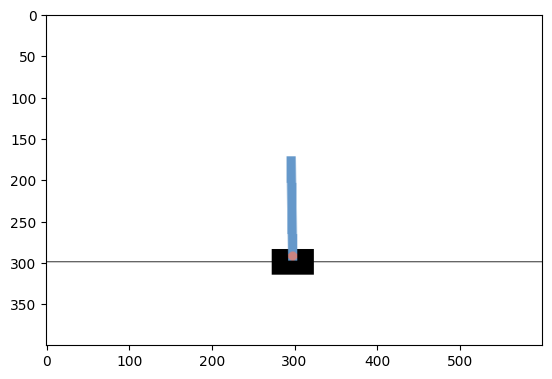

In [4]:
# Create the environment
env = gym.make('CartPole-v1', render_mode = 'rgb_array')
# Let's print the information of the observation and action spaces
print(f'Observation Type: {env.observation_space}, Action Type: {env.action_space}')
# Now let's print a sample from the observation and action spaces
print(f'Observation sample: {env.observation_space.sample()}, Action sample: {env.action_space.sample()}')

# Let's get the first frame
env.reset()
image = env.render()
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
plt.imshow(image)

## DQN Agent

The DQNAgent uses a neural network defined in the QNetwork module. In this case, the network is composed by 3 linear layers. More complex problems can use more complex neural networks, for example CNNs for environments where observations are images, or RNNs to handle time series.

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

The agent has a function called `select_action(self, state)` that performs the same function as the `choose_e_greedy_action(self, observation)` in Q-Learning. In this case, the implementation also follows the $ϵ$-greedy strategy. Other deep-reinforcement learning methods will implement alternatives to this function.

The agent also implements an experience replay, called memory.

In [6]:
class DQNAgent:
    def __init__(self, state_size, action_size, batch_size, gamma, epsilon, \
                 epsilon_decay, epsilon_min):
        # Agent properties
        self.state_size = state_size
        self.action_size = action_size
        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        # Experience replay
        self.memory = deque(maxlen=2000)

        # Device for training
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # Define the Q-network
        self.q_network = QNetwork(state_size, action_size).to(self.device)
        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.001)

    # Select the action for a given state(observation)
    def select_action(self, state):
        # Select a random action
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        # or select the action learnt by the network.
        # first move the state to the device (correcting dimensions)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        # obtain the Q-value from the network. Notice the no_grad to avoid
        # gradient propagation
        with torch.no_grad():
            action_values = self.q_network(state)
        # Return the argmax value
        return torch.argmax(action_values).item()

    # Function to store an experience
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    # This function performs the training of the network using the experience
    # replay. To train the network we will sample the experience replay
    # randomly to create a batch.
    def replay(self):
        # skip training if don't have enough samples
        if len(self.memory) < self.batch_size:
            return

        # sample a batch from the memory
        batch = random.sample(self.memory, self.batch_size)
        # Get the selected experience vectors
        states, actions, rewards, next_states, dones = zip(*batch)

        # Move the data to PyTorch tensor and to the device
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Call the network to obtain the Q-values for the current action
        q_values = self.q_network(states).gather(1, actions)
        # Get the max Q-value for the actions in the next states
        next_q_values = self.q_network(next_states).max(1)[0].unsqueeze(1)
        # Calculate the target Q-value
        target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        # Define the loss function so that the network learns to predict
        # the target Q-value
        loss = F.mse_loss(q_values, target_q_values)

        # Initialize to 0 the gradients
        self.optimizer.zero_grad()
        # Do backpropagation
        loss.backward()
        # Perform the optimization step
        self.optimizer.step()

        # Finally update the value of epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

Remember the update rule for Q-Learning:

$$ Q(S_t, A_t, \mathbf{\text{w}}_t) = Q(S_t, A_t, \mathbf{\text{w}}_t) + \alpha(R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a, \mathbf{\text{w}}_t^{-}) - Q(S_t, A_t, \mathbf{\text{w}}_t)) $$

We are approximating $Q(S_t, A_t, \mathbf{\text{w}}_t)$, so this is our estimate. To update the NN, we need the observations, that we obtain from experience, and the true values or labels, corresponding to these observations. To obtain these labels we need the unbiased estimate of the state value function, that we obtain from experience too:

$$ U_t = R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a, \mathbf{\text{w}}_t^{-}) $$

also called the TD target. We already have $R_{t+1}$ and $S_{t+1}$ from experience, but we need the Q-value from the best action from this state. This Q-value is computed from the 'target' network, which is the one we update once every $t$ steps.

The TD target gives us the approximation for $Q(S_t, A_t, \mathbf{\text{w}}_t)$, i.e., only for the action $A_t$ of the sample of experience we are considering. The rest of the Q-values for state $S_t$ are the same, and are obtained from the 'online' network.

By updating the Q-values from the 'online' network for action $A_t$ with the TD target computed from the 'target' network, we obtain the true values that will serve as labels for updating the 'online' network.

## Training

In [7]:
# Create the environment
env = gym.make("CartPole-v1", render_mode='rgb_array')

# Define the hyperparameters of the agent
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
batch_size = 32
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

# Create the agent
agent = DQNAgent(state_size, action_size, batch_size, gamma, epsilon, epsilon_decay, epsilon_min)

# Define basic parameters to control the training
EPISODES = 10_000
MAX_TIMESTEPS = 500

# Define some variables to store training progress data
score_history = []
average_score = 0.0

for episode in range(EPISODES):
    state, _ = env.reset()
    score = 0

    # We run the environment until it is done or we have performed MAX_TIMESTEPS
    for t in range(MAX_TIMESTEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # store the experience
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        score += reward

        if done:
            break

    # store the score obtained in the last episode
    score_history.append(score)

    # We will print progress information every 100 episodes
    if (episode+1) % 100 == 0:
        average_score = sum(score_history[-100:]) / 100
        print(f"Episode {episode + 1}/{EPISODES} | Average Reward (Last 100 episodes): {average_score:.2f}")

    # Call replay to perform the training of the NN
    agent.replay()

    # If the average score is above 195 we are done
    if average_score >= 195:
        print(f"Environment solved in {episode + 1} episodes!")
        break

# Close the environment
env.close()

<ipython-input-6-31434dc06714>:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  states = torch.FloatTensor(states).to(self.device)


Episode 100/10000 | Average Reward (Last 100 episodes): 22.68
Episode 200/10000 | Average Reward (Last 100 episodes): 18.55
Episode 300/10000 | Average Reward (Last 100 episodes): 14.62
Episode 400/10000 | Average Reward (Last 100 episodes): 13.22
Episode 500/10000 | Average Reward (Last 100 episodes): 10.99
Episode 600/10000 | Average Reward (Last 100 episodes): 13.87
Episode 700/10000 | Average Reward (Last 100 episodes): 13.85
Episode 800/10000 | Average Reward (Last 100 episodes): 23.40
Episode 900/10000 | Average Reward (Last 100 episodes): 52.55
Episode 1000/10000 | Average Reward (Last 100 episodes): 251.77
Environment solved in 1000 episodes!


Let's visualize the score history to visualize the training progress of our agent:

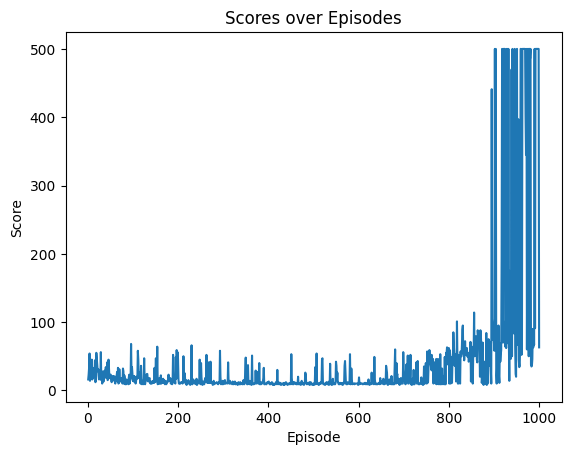

In [8]:
episodes = list(range(1, len(score_history)+1))
plt.plot(episodes, score_history)
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Scores over Episodes')
plt.show()

The history is very noisy, for this reason it is typical to visualize a moving average, where we average the score of the episodes in a window:

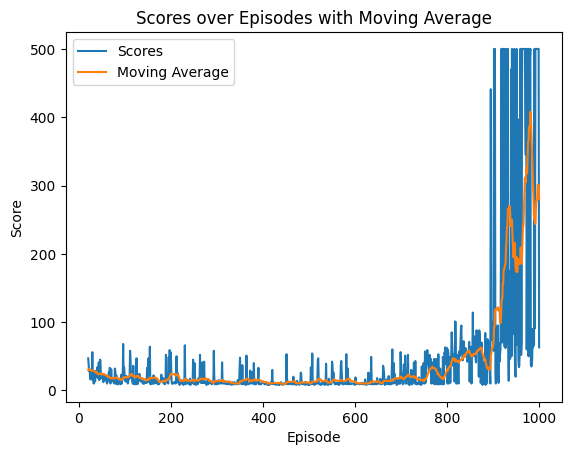

In [9]:
import numpy as np

# Calculate the moving average
window_size = 20
moving_average = np.convolve(score_history, np.ones(window_size), 'valid') / window_size

# Generate x-axis values
episodes = list(range(window_size, len(score_history)+1))

# Plot the scores and moving average
plt.plot(episodes, score_history[window_size-1:], label='Scores')
plt.plot(episodes, moving_average, label='Moving Average')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Scores over Episodes with Moving Average')
plt.legend()
plt.show()

## Testing

Finally let's see how our agent behaves in a number of episodes:

In [10]:
EPISODES = 10

env = gym.make("CartPole-v1", render_mode='rgb_array')

scores = []

for episode in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        state = next_state
        score += reward

        if done:
            break

    scores.append(score)
    print(f"Episode {episode + 1}/{EPISODES} - Score: {score}")

env.close()

average_score = sum(scores) / EPISODES
print(f"\nAverage Score (Over {EPISODES} episodes): {average_score:.2f}")

Episode 1/10 - Score: 65.0
Episode 2/10 - Score: 71.0
Episode 3/10 - Score: 75.0
Episode 4/10 - Score: 127.0
Episode 5/10 - Score: 57.0
Episode 6/10 - Score: 77.0
Episode 7/10 - Score: 500.0
Episode 8/10 - Score: 76.0
Episode 9/10 - Score: 500.0
Episode 10/10 - Score: 500.0

Average Score (Over 10 episodes): 204.80


In [11]:
observation, _ = env.reset()
done = False
images = []
while not done:
    action = agent.select_action(observation)
    observation, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    image = env.render()
    images.append(image)

    if len(images) > 100:
        done = True

save_video(images, path='/content/DQN_cartpole.mp4')

Video saved.


# Two network optimization

In previous code we were using to select the actions the same network that we were training. Using two networks can help improve the stability:

1. One network is used as policy to select the next action
2. The second network is being trained.

The code is mostly the same as in the previous example except in the points commented below:

In [12]:
class DQNAgent2:
    def __init__(self, state_size, action_size, batch_size, gamma, epsilon, epsilon_decay, epsilon_min, num_sync):
        self.state_size = state_size
        self.action_size = action_size
        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.memory = deque(maxlen=2000)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.num_sync = num_sync
        self.sync_counter = 0

        # Define the Q-network and target network
        self.q_network = QNetwork(state_size, action_size).to(self.device)
        self.target_network = QNetwork(state_size, action_size).to(self.device)

        # Copy the state of the two networks. We use the load_state_dict function
        # to copy the parameters of the network
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.001)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action_values = self.q_network(state)
        return torch.argmax(action_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        q_values = self.q_network(states).gather(1, actions)
        # Notice that we use the target network to evaluate the Q-value of the
        # next state
        next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
        target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        loss = F.mse_loss(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Synchronize the target network with the Q-network every num_sync steps
        self.sync_counter += 1
        if self.sync_counter % self.num_sync == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

In this modified version of the DQNAgent class, we added the `target_network` attribute, which is initially synchronized with the q_network in the `__init__` method using `load_state_dict`. The target_network is then kept fixed during the replay process.

After each optimization step, we increment the sync_counter and check if it's time to synchronize the target_network with the q_network. If the sync_counter reaches num_sync, we update the target_network using load_state_dict to copy the weights from the q_network.

By using a separate target_network, we can stabilize the learning process and avoid the problem of overestimating action values during training.

## Training

The training is the same as before

In [13]:
env = gym.make("CartPole-v1", render_mode='rgb_array')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

batch_size = 32
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

agent = DQNAgent2(state_size, action_size, batch_size, gamma, epsilon, epsilon_decay, epsilon_min, 100)

EPISODES = 10_000
MAX_TIMESTEPS = 500
score_history = []

for episode in range(EPISODES):
    state, _ = env.reset()
    score = 0

    for t in range(MAX_TIMESTEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        state = next_state
        score += reward

        if done:
            break

    score_history.append(score)
    if episode % 100 == 0:
        average_score = sum(score_history[-100:]) / 100
        print(f"Episode {episode + 1}/{EPISODES} - Score: {score} - Average Score (Last 100 episodes): {average_score:.2f}")

    agent.replay()

    if average_score >= 195:
        print(f"Environment solved in {episode + 1} episodes!")
        break

env.close()

Episode 1/10000 - Score: 22.0 - Average Score (Last 100 episodes): 0.22
Episode 101/10000 - Score: 16.0 - Average Score (Last 100 episodes): 22.15
Episode 201/10000 - Score: 10.0 - Average Score (Last 100 episodes): 14.15
Episode 301/10000 - Score: 13.0 - Average Score (Last 100 episodes): 12.06
Episode 401/10000 - Score: 12.0 - Average Score (Last 100 episodes): 11.10
Episode 501/10000 - Score: 12.0 - Average Score (Last 100 episodes): 10.98
Episode 601/10000 - Score: 8.0 - Average Score (Last 100 episodes): 11.43
Episode 701/10000 - Score: 10.0 - Average Score (Last 100 episodes): 9.95
Episode 801/10000 - Score: 11.0 - Average Score (Last 100 episodes): 14.32
Episode 901/10000 - Score: 32.0 - Average Score (Last 100 episodes): 20.63
Episode 1001/10000 - Score: 18.0 - Average Score (Last 100 episodes): 38.45
Episode 1101/10000 - Score: 28.0 - Average Score (Last 100 episodes): 32.31
Episode 1201/10000 - Score: 50.0 - Average Score (Last 100 episodes): 61.11
Episode 1301/10000 - Score:

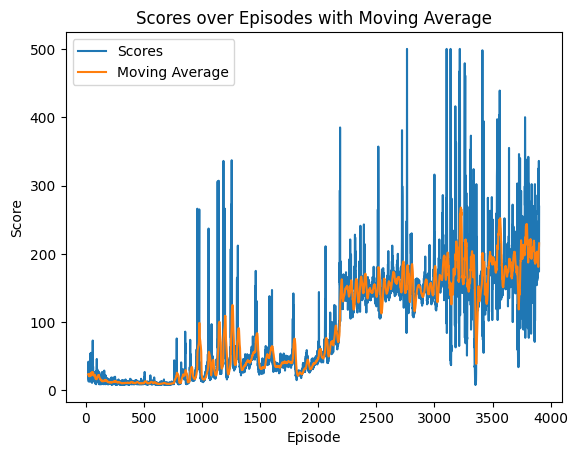

In [14]:
import numpy as np

# Calculate the moving average
window_size = 20
moving_average = np.convolve(score_history, np.ones(window_size), 'valid') / window_size

# Generate x-axis values
episodes = list(range(window_size, len(score_history)+1))

# Plot the scores and moving average
plt.plot(episodes, score_history[window_size-1:], label='Scores')
plt.plot(episodes, moving_average, label='Moving Average')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Scores over Episodes with Moving Average')
plt.legend()
plt.show()

## Testing

We can evaluate the behaviour of the agent:

In [15]:
EPISODES = 10

env = gym.make("CartPole-v1", render_mode='rgb_array')

scores = []

for episode in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        state = next_state
        score += reward

        if done:
            break

    scores.append(score)
    print(f"Episode {episode + 1}/{EPISODES} - Score: {score}")

env.close()

average_score = sum(scores) / EPISODES
print(f"\nAverage Score (Over {EPISODES} episodes): {average_score:.2f}")

Episode 1/10 - Score: 358.0
Episode 2/10 - Score: 116.0
Episode 3/10 - Score: 398.0
Episode 4/10 - Score: 274.0
Episode 5/10 - Score: 253.0
Episode 6/10 - Score: 132.0
Episode 7/10 - Score: 67.0
Episode 8/10 - Score: 243.0
Episode 9/10 - Score: 269.0
Episode 10/10 - Score: 278.0

Average Score (Over 10 episodes): 238.80


Let's generate a video:

In [16]:
observation, _ = env.reset()
done = False
images = []
while not done:
    action = agent.select_action(observation)
    observation, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    image = env.render()
    images.append(image)

    if len(images) > 100:
        done = True

save_video(images, path='/content/DQN2_cartpole.mp4')

Video saved.


# Appendix